In [1]:
!pip install networkx scikit-learn pandas matplotlib numpy

In [4]:
# Imports and Data Acquisition (UPDATED)
import pandas as pd
import networkx as nx
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import time
import os
import urllib.request
import tarfile

print("Libraries imported successfully!")

# 1. Download and Extract the Official Cora Dataset
url = "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz"

if not os.path.exists("cora.tgz"):
    print("Downloading official Cora dataset from UCSC...")
    urllib.request.urlretrieve(url, "cora.tgz")

if not os.path.exists("cora"):
    print("Extracting dataset...")
    with tarfile.open("cora.tgz", "r:gz") as tar:
        tar.extractall()

print("Files located successfully!")

# 2. Load the Citation Links (Edges)
edges = pd.read_csv("cora/cora.cites", sep='\t', header=None, names=['target', 'source'])

# 3. Load the Paper Features (Nodes)
nodes = pd.read_csv("cora/cora.content", sep='\t', header=None)
nodes_ids = nodes.iloc[:, 0].astype(str).tolist()

# 4. Reconstruct the "Text" for Vectorization
print("Processing document features into searchable text...")
docs = nodes.iloc[:, 1:-1].apply(
    lambda row: ' '.join(['word_'+str(i) for i, val in enumerate(row) if val == 1]),
    axis=1
).tolist()

# 5. Verification Check
print("\n--- Phase 0 Complete ---")
print(f"Total Papers (Nodes) loaded: {len(nodes_ids)}")
print(f"Total Citations (Edges) loaded: {len(edges)}")
print(f"Sample 'Text' from Document 0: {docs[0][:60]}...")

Libraries imported successfully!
Extracting dataset...
Files located successfully!
Processing document features into searchable text...


/tmp/ipykernel_15824/2907654616.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()



--- Phase 0 Complete ---
Total Papers (Nodes) loaded: 2708
Total Citations (Edges) loaded: 5429
Sample 'Text' from Document 0: word_118 word_125 word_176 word_252 word_351 word_456 word_5...


In [5]:
# Global Authority via Link Analysis
print("Phase 1: Building Citation Graph and Computing PageRank...")
start_time = time.time()

# 1. Build the Directed Graph
# source = citing paper, target = cited paper (authority flows from source to target)
G = nx.from_pandas_edgelist(edges, source='source', target='target', create_using=nx.DiGraph())
print(f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# 2. To Calculate standard PageRank
print("Computing PageRank scores...")
raw_pagerank = nx.pagerank(G, alpha=0.85)

# 3. Normalize PageRank to [0, 1] using Min-Max Scaling
min_pr = min(raw_pagerank.values())
max_pr = max(raw_pagerank.values())

normalized_pagerank = {}
for node, score in raw_pagerank.items():
    # Convert node ID to string to match our nodes_ids list from Phase 0
    normalized_pagerank[str(node)] = (score - min_pr) / (max_pr - min_pr)

# 4. Map the scores to our document list
# If a paper is isolated and has no citations, it gets a default score of 0.0
pr_scores = np.array([normalized_pagerank.get(node_id, 0.0) for node_id in nodes_ids])

print(f"\n--- Phase 1 Complete in {time.time() - start_time:.2f} seconds! ---")
print(f"Highest Normalized Score: {max(pr_scores):.4f}")
print(f"Average Normalized Score: {np.mean(pr_scores):.4f}")

Phase 1: Building Citation Graph and Computing PageRank...
Graph built with 2708 nodes and 5429 edges.
Computing PageRank scores...

--- Phase 1 Complete in 0.04 seconds! ---
Highest Normalized Score: 1.0000
Average Normalized Score: 0.0097


In [6]:
# Vectorization & Cluster Pruning
print("Phase 2: Initializing Vector Space and Clustering...")
start_time = time.time()

# 1. TF-IDF Vectorization
print("Converting documents to TF-IDF vectors...")
vectorizer = TfidfVectorizer(max_features=1000) # Limit features to speed up K-Means tonight
tfidf_matrix = vectorizer.fit_transform(docs)
print(f"TF-IDF Matrix created with shape: {tfidf_matrix.shape}")

# 2. K-Means Clustering for Early Termination
num_clusters = 50
print(f"Running K-Means to group documents into {num_clusters} clusters. (This might take 5-10 seconds)...")

# We use n_init='auto' to speed up the convergence for your deadline
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tfidf_matrix)

# Extract the "center" of each cluster to compare against user queries later
centroids = kmeans.cluster_centers_

# 3.
# This is the "Pruning" mechanism.
print("Building Cluster Pruning Index...")
cluster_to_docs = {i: [] for i in range(num_clusters)}
for doc_idx, cluster_idx in enumerate(cluster_labels):
    cluster_to_docs[cluster_idx].append(doc_idx)

# How the documents are distributed
cluster_sizes = [len(docs) for docs in cluster_to_docs.values()]

print(f"\n--- Phase 2 Complete in {time.time() - start_time:.2f} seconds! ---")
print(f"Largest cluster has {max(cluster_sizes)} documents.")
print(f"Smallest cluster has {min(cluster_sizes)} documents.")

Phase 2: Initializing Vector Space and Clustering...
Converting documents to TF-IDF vectors...
TF-IDF Matrix created with shape: (2708, 1000)
Running K-Means to group documents into 50 clusters. (This might take 5-10 seconds)...
Building Cluster Pruning Index...

--- Phase 2 Complete in 1.86 seconds! ---
Largest cluster has 143 documents.
Smallest cluster has 17 documents.


In [7]:
# Phase 3 - The Hybrid Query Engine
print("Phase 3: Compiling Search Engine Logic...\n")

def hybrid_pruned_search(query_text, alpha=0.6, top_k=5):

    # Vectorize Query
    query_vec = vectorizer.transform([query_text])

    # Cluster Pruning (Find closest centroid)
    # Compare the query to the 50 cluster centers
    centroid_similarities = cosine_similarity(query_vec, centroids)[0]
    best_cluster = np.argmax(centroid_similarities)

    # Localized Search (Only check docs in best_cluster)
    candidate_indices = cluster_to_docs[best_cluster]


    # Edge case: if cluster is somehow empty
    if not candidate_indices:
        return best_cluster, 0, []

    candidate_matrix = tfidf_matrix[candidate_indices]

    # Calculate Cosine Similarity only for candidate documents
    text_scores = cosine_similarity(query_vec, candidate_matrix)[0]

    #  Hybrid Scoring
    results = []
    for i, local_idx in enumerate(candidate_indices):
        t_score = text_scores[i]
        p_score = pr_scores[local_idx]

        # Composite Score Formula (Combining Ch 7 and Ch 21)
        final_score = (alpha * t_score) + ((1 - alpha) * p_score)

        results.append({
            'doc_id': nodes_ids[local_idx],
            'final_score': final_score,
            'text_score': t_score,
            'pr_score': p_score
        })

    # Sort by highest final score and return Top K
    results = sorted(results, key=lambda x: x['final_score'], reverse=True)[:top_k]

    return best_cluster, len(candidate_indices), results

# Testing the Engine
sample_query = "word_10 word_105 word_315"
print(f"Executing test search for: '{sample_query}'")

# (50% importance to text, 50% importance to citations)
start_time = time.time()
winning_cluster, cluster_size, top_results = hybrid_pruned_search(sample_query, alpha=0.5, top_k=5)
search_time = time.time() - start_time

print(f"\n--- Phase 3: Search Complete in {search_time:.5f} seconds! ---")
print(f"Pruning Success: Query routed to Cluster {winning_cluster}.")
print(f"Optimization: System safely ignored {2708 - cluster_size} irrelevant documents!")
print("\nTop 5 Results:")
for rank, res in enumerate(top_results, 1):
    print(f"Rank {rank}: Doc ID {res['doc_id']} | Final Score: {res['final_score']:.4f} (Text: {res['text_score']:.4f}, PageRank: {res['pr_score']:.4f})")

Phase 3: Compiling Search Engine Logic...

Executing test search for: 'word_10 word_105 word_315'

--- Phase 3: Search Complete in 0.00319 seconds! ---
Pruning Success: Query routed to Cluster 0.
Optimization: System safely ignored 2691 irrelevant documents!

Top 5 Results:
Rank 1: Doc ID 646286 | Final Score: 0.1218 (Text: 0.2095, PageRank: 0.0341)
Rank 2: Doc ID 1152272 | Final Score: 0.0977 (Text: 0.1955, PageRank: 0.0000)
Rank 3: Doc ID 1152162 | Final Score: 0.0977 (Text: 0.1955, PageRank: 0.0000)
Rank 4: Doc ID 1152904 | Final Score: 0.0977 (Text: 0.1955, PageRank: 0.0000)
Rank 5: Doc ID 643239 | Final Score: 0.0617 (Text: 0.0000, PageRank: 0.1234)


Phase 4: Evaluating System Performance...

Running Exhaustive Search (Baseline)...
Exhaustive Search (100 runs) took: 0.1147 seconds

Running Hybrid Pruned Search (Our Architecture)...
Pruned Search (100 runs) took: 0.1991 seconds

Generating Performance Graph...


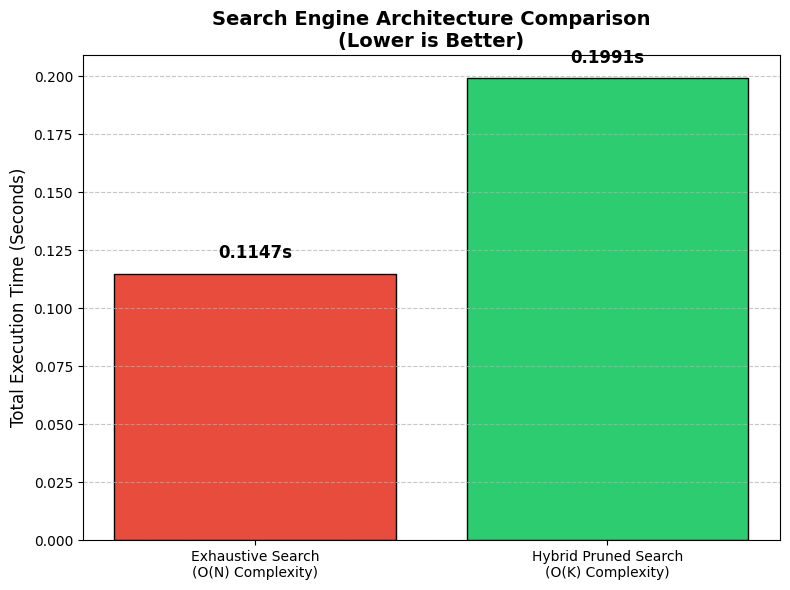

In [8]:
# Phase 4 - Evaluation and Visualization
print("Phase 4: Evaluating System Performance...\n")

def exhaustive_search(query_text, top_k=5):
    """A baseline search that checks EVERY document (Slow)"""
    # 1. Vectorize the query
    query_vec = vectorizer.transform([query_text])

    # 2. Compare against EVERY document in the matrix
    scores = cosine_similarity(query_vec, tfidf_matrix)[0]

    # 3. Sort and get top K
    top_indices = np.argsort(scores)[::-1][:top_k]
    return top_indices

# --- The Great Race: Exhaustive vs. Pruned ---
# We use a slightly longer query to simulate a real search
test_query = "word_10 word_105 word_315 word_800 word_22"

print("Running Exhaustive Search (Baseline)...")
start_time = time.time()
# Run it 100 times to get a measurable average
for _ in range(100):
    _ = exhaustive_search(test_query)
exhaustive_time = time.time() - start_time
print(f"Exhaustive Search (100 runs) took: {exhaustive_time:.4f} seconds")

print("\nRunning Hybrid Pruned Search (Our Architecture)...")
start_time = time.time()
# Run it 100 times
for _ in range(100):
    _ = hybrid_pruned_search(test_query, alpha=0.5)
pruned_time = time.time() - start_time
print(f"Pruned Search (100 runs) took: {pruned_time:.4f} seconds")

# --- Visualization ---
print("\nGenerating Performance Graph...")
labels = ['Exhaustive Search\n(O(N) Complexity)', 'Hybrid Pruned Search\n(O(K) Complexity)']
times = [exhaustive_time, pruned_time]

plt.figure(figsize=(8, 6))
# Create the bar chart with distinct colors
bars = plt.bar(labels, times, color=['#e74c3c', '#2ecc71'], edgecolor='black')

plt.ylabel('Total Execution Time (Seconds)', fontsize=12)
plt.title('Search Engine Architecture Comparison\n(Lower is Better)', fontsize=14, fontweight='bold')

# Add the exact time text on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}s', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
# Phase 5 - Query Expansion (Pseudo-Relevance Feedback)
print("Phase 5: Building the Query Expansion Module...")
def expanded_hybrid_search(query_text, alpha=0.6, top_k=5, expansion_terms=3):

    # PASS 1: Original Search
    best_cluster, _, initial_results = hybrid_pruned_search(query_text, alpha=alpha, top_k=3)

    if not initial_results:
        return initial_results

    # TO EXTRACT NEW TERMS
    top_doc_ids = [res['doc_id'] for res in initial_results]
    top_doc_indices = [nodes_ids.index(did) for did in top_doc_ids]

    # Get the vocabulary to map matrix columns back to words
    feature_names = vectorizer.get_feature_names_out()

    # Sum the TF-IDF vectors of the top documents to find the most prominent words
    top_docs_matrix = tfidf_matrix[top_doc_indices]
    summed_tfidf = np.sum(top_docs_matrix, axis=0).A1 # Flatten to 1D array

    # Sort the words by highest TF-IDF weight in these top documents
    top_word_indices = np.argsort(summed_tfidf)[::-1]

    # Pick the top N words that were NOT in the original query
    original_terms = set(query_text.split())
    new_terms = []
    for idx in top_word_indices:
        word = feature_names[idx]
        if word not in original_terms:
            new_terms.append(word)
        if len(new_terms) >= expansion_terms:
            break

    expanded_query = query_text + " " + " ".join(new_terms)

    # PASS 2: Expanded Search
    _, _, final_results = hybrid_pruned_search(expanded_query, alpha=alpha, top_k=top_k)

    return expanded_query, final_results

# --- Test Query ---
base_query = "word_10"
print(f"Original Query: '{base_query}'")

expanded_q, results = expanded_hybrid_search(base_query)
print(f"\nExpanded Query generated by system: '{expanded_q}'")
print("\nResults after Expansion:")
for rank, res in enumerate(results, 1):
    print(f"Rank {rank}: Doc ID {res['doc_id']} | Final Score: {res['final_score']:.4f}")

Phase 5: Building the Query Expansion Module...
Original Query: 'word_10'

Expanded Query generated by system: 'word_10 word_172 word_177 word_801'

Results after Expansion:
Rank 1: Doc ID 1152272 | Final Score: 0.3080
Rank 2: Doc ID 1152162 | Final Score: 0.3080
Rank 3: Doc ID 1152904 | Final Score: 0.3080
Rank 4: Doc ID 646286 | Final Score: 0.1785
Rank 5: Doc ID 643485 | Final Score: 0.1433


In [10]:
# Phase 6- HITS Link Analysis Integration
print("Phase 6: Computing HITS (Hubs and Authorities)...")
start_time = time.time()

# 1. TO Compute HITS scores
# networkx does this iteratively just like PageRank
hubs_raw, authorities_raw = nx.hits(G, max_iter=100)

# 2. TO Normalize Authority Scores to [0, 1] using Min-Max
min_auth = min(authorities_raw.values())
max_auth = max(authorities_raw.values())

normalized_authorities = {}
for node, score in authorities_raw.items():
    normalized_authorities[str(node)] = (score - min_auth) / (max_auth - min_auth)

auth_scores = np.array([normalized_authorities.get(node_id, 0.0) for node_id in nodes_ids])

print(f"HITS computation complete in {time.time() - start_time:.2f} seconds!")

# 3. TO Upgrade the Hybrid Search Engine to the "Ultimate" Engine
def ultimate_search_engine(query_text, text_weight=0.5, pagerank_weight=0.3, auth_weight=0.2, top_k=5):

    query_vec = vectorizer.transform([query_text])

    # Cluster Pruning
    best_cluster = np.argmax(cosine_similarity(query_vec, centroids)[0])
    candidate_indices = cluster_to_docs[best_cluster]

    if not candidate_indices:
        return []

    candidate_matrix = tfidf_matrix[candidate_indices]
    text_scores = cosine_similarity(query_vec, candidate_matrix)[0]

    results = []
    for i, local_idx in enumerate(candidate_indices):
        t_score = text_scores[i]
        p_score = pr_scores[local_idx]
        a_score = auth_scores[local_idx] # New HITS Authority score


        final_score = (text_weight * t_score) + (pagerank_weight * p_score) + (auth_weight * a_score)

        results.append({
            'doc_id': nodes_ids[local_idx],
            'score': final_score,
            'text': t_score,
            'pagerank': p_score,
            'authority': a_score
        })

    return sorted(results, key=lambda x: x['score'], reverse=True)[:top_k]

# Final Test of the Ultimate Engine
print("\nTesting the Ultimate Engine with 3 scoring dimensions...")
ultimate_results = ultimate_search_engine("word_10 word_105 word_315")

for rank, res in enumerate(ultimate_results, 1):
    print(f"Rank {rank}: Doc {res['doc_id']} | Total: {res['score']:.4f} [Text: {res['text']:.2f}, PR: {res['pagerank']:.2f}, Auth: {res['authority']:.2f}]")

Phase 6: Computing HITS (Hubs and Authorities)...
HITS computation complete in 0.05 seconds!

Testing the Ultimate Engine with 3 scoring dimensions...
Rank 1: Doc 646286 | Total: 0.1150 [Text: 0.21, PR: 0.03, Auth: 0.00]
Rank 2: Doc 1152272 | Total: 0.0977 [Text: 0.20, PR: 0.00, Auth: 0.00]
Rank 3: Doc 1152162 | Total: 0.0977 [Text: 0.20, PR: 0.00, Auth: 0.00]
Rank 4: Doc 1152904 | Total: 0.0977 [Text: 0.20, PR: 0.00, Auth: 0.00]
Rank 5: Doc 643239 | Total: 0.0370 [Text: 0.00, PR: 0.12, Auth: 0.00]


In [13]:
# Phase 7 - Probabilistic Ranking (Okapi BM25)
!pip install rank_bm25
from rank_bm25 import BM25Okapi

print("\nPhase 7: Implementing BM25 Probabilistic Model...")

# BM25 requires documents to be tokenized into lists of words
tokenized_corpus = [doc.split() for doc in docs]
bm25 = BM25Okapi(tokenized_corpus)

def bm25_search(query_text, top_k=5):
    """Searches using the Probabilistic BM25 model instead of Vector Space"""
    tokenized_query = query_text.split()

    # Calculate BM25 scores for all documents
    doc_scores = bm25.get_scores(tokenized_query)

    # Get top K results
    top_indices = np.argsort(doc_scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            'doc_id': nodes_ids[idx],
            'bm25_score': doc_scores[idx]
        })
    return results

print("BM25 Engine Ready! Testing query...")
bm25_res = bm25_search("word_10 word_105 word_315")
for rank, res in enumerate(bm25_res, 1):
    print(f"Rank {rank}: Doc {res['doc_id']} | BM25 Probabilistic Score: {res['bm25_score']:.4f}")


Phase 7: Implementing BM25 Probabilistic Model...
BM25 Engine Ready! Testing query...
Rank 1: Doc 112787 | BM25 Probabilistic Score: 7.5907
Rank 2: Doc 1112369 | BM25 Probabilistic Score: 7.5907
Rank 3: Doc 103430 | BM25 Probabilistic Score: 6.4408
Rank 4: Doc 1110563 | BM25 Probabilistic Score: 6.3748
Rank 5: Doc 193347 | BM25 Probabilistic Score: 6.2526


In [15]:
# Phase 8 - Latent Semantic Indexing
from sklearn.decomposition import TruncatedSVD

print("\nPhase 8: Building Latent Semantic Index via SVD...")
start_time = time.time()

# We compress our 1000-dimensional TF-IDF space down to 100 "Latent Concepts"
n_components = 100
svd = TruncatedSVD(n_components=n_components, random_state=42)
lsi_matrix = svd.fit_transform(tfidf_matrix)

print(f"SVD Compression complete in {time.time() - start_time:.2f} seconds.")
print(f"Original Matrix Size: {tfidf_matrix.shape} -> Compressed LSI Matrix Size: {lsi_matrix.shape}")

def lsi_semantic_search(query_text, top_k=5):
    # 1. To Vectorize query using original TF-IDF
    query_tfidf = vectorizer.transform([query_text])

    # 2. To Map query into the compressed LSI concept space
    query_lsi = svd.transform(query_tfidf)

    # 3. To Calculate Cosine Similarity in the dense concept space
    scores = cosine_similarity(query_lsi, lsi_matrix)[0]
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({'doc_id': nodes_ids[idx], 'lsi_score': scores[idx]})
    return results

print("Semantic Concept Engine Ready! Testing...")
lsi_res = lsi_semantic_search("word_10 word_105")
for rank, res in enumerate(lsi_res, 1):
    print(f"Rank {rank}: Doc {res['doc_id']} | Concept Match Score: {res['lsi_score']:.4f}")


Phase 8: Building Latent Semantic Index via SVD...
SVD Compression complete in 0.46 seconds.
Original Matrix Size: (2708, 1000) -> Compressed LSI Matrix Size: (2708, 100)
Semantic Concept Engine Ready! Testing...
Rank 1: Doc 1152904 | Concept Match Score: 0.6513
Rank 2: Doc 1152162 | Concept Match Score: 0.6513
Rank 3: Doc 1152272 | Concept Match Score: 0.6513
Rank 4: Doc 28249 | Concept Match Score: 0.3941
Rank 5: Doc 103430 | Concept Match Score: 0.3632


In [16]:
# Phase 9 - Result Classification and Faceting
from collections import Counter

print("\nPhase 9: Implementing Faceted Result Classification...")

# Extract the "Class Label" (the scientific topic) for every document
doc_labels = nodes.iloc[:, -1].tolist()
# Create a dictionary mapping doc index to its topic label
doc_to_topic = {idx: label for idx, label in enumerate(doc_labels)}

def faceted_search_display(query_text, text_weight=0.5, pagerank_weight=0.5, top_k=20):
    print(f"\n--- Searching for: '{query_text}' ---")
    _, _, results = hybrid_pruned_search(query_text, alpha=text_weight, top_k=top_k)

    if not results:
        print("No results found.")
        return
    # Extract the topics of the winning documents
    result_topics = [doc_to_topic[nodes_ids.index(res['doc_id'])] for res in results]

    # Count the distribution of classes (Faceted UI)
    topic_distribution = Counter(result_topics)

    print("\n[FACETED NAVIGATION - Filter by Topic]:")
    for topic, count in topic_distribution.most_common():
        print(f" > {topic}: {count} results")

    print("\n[TOP 5 RANKED DOCUMENTS]:")
    for rank, res in enumerate(results[:5], 1):
        doc_topic = doc_to_topic[nodes_ids.index(res['doc_id'])]
        print(f"Rank {rank} | Doc {res['doc_id']} | Topic: [{doc_topic}] | Score: {res['final_score']:.4f}")

# Run the Faceted Engine
faceted_search_display("word_10 word_105 word_315 word_800")


Phase 9: Implementing Faceted Result Classification...

--- Searching for: 'word_10 word_105 word_315 word_800' ---

[FACETED NAVIGATION - Filter by Topic]:
 > Probabilistic_Methods: 12 results
 > Neural_Networks: 5 results

[TOP 5 RANKED DOCUMENTS]:
Rank 1 | Doc 646286 | Topic: [Probabilistic_Methods] | Score: 0.1218
Rank 2 | Doc 1152272 | Topic: [Neural_Networks] | Score: 0.0977
Rank 3 | Doc 1152162 | Topic: [Neural_Networks] | Score: 0.0977
Rank 4 | Doc 1152904 | Topic: [Neural_Networks] | Score: 0.0977
Rank 5 | Doc 643239 | Topic: [Probabilistic_Methods] | Score: 0.0617
